In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import ssl


In [49]:
# Para evitar erro de SSL em macOS (meu caso)
ssl._create_default_https_context = ssl._create_unverified_context

In [50]:
# Carregar o Seeds Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
colunas = ['area', 'perimetro', 'compacidade', 'comprimento_grao',
           'largura_grao', 'assimetria', 'comprimento_sulco', 'classe']


In [51]:
df = pd.read_csv(url, sep=r'\s+', header=None, names=colunas)

In [52]:
# Separar atributos (X) e rótulo (y)
X = df.drop(columns=['classe'])
y = df['classe']

In [53]:
# Dividir entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [54]:
# Criar o modelo Naive Bayes (Gaussiano)
modelo_nb = GaussianNB()

In [55]:
# Treinar o modelo
modelo_nb.fit(X_train, y_train)

GaussianNB()

In [56]:
# Fazer previsões
y_pred = modelo_nb.predict(X_test)

In [57]:
# Avaliar o modelo
print("=== RESULTADOS - NAIVE BAYES NO SEEDS DATASET ===\n")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")

# Nomes das sementes para o relatório
nomes_sementes = ['Kama', 'Rosa', 'Canadian']
print("\nRelatório de Classificação:\n",
      classification_report(y_test, y_pred, target_names=nomes_sementes))

=== RESULTADOS - NAIVE BAYES NO SEEDS DATASET ===

Acurácia: 0.8254

Relatório de Classificação:
               precision    recall  f1-score   support

        Kama       0.73      0.76      0.74        21
        Rosa       0.94      0.76      0.84        21
    Canadian       0.83      0.95      0.89        21

    accuracy                           0.83        63
   macro avg       0.83      0.83      0.83        63
weighted avg       0.83      0.83      0.83        63



In [58]:
# GRÁFICO Matriz de Confusão
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)

<Figure size 600x400 with 0 Axes>

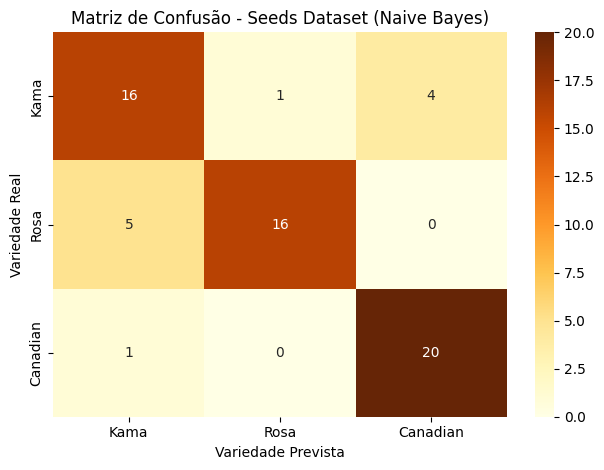

In [59]:
# Criar o mapa de calor
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=nomes_sementes,
            yticklabels=nomes_sementes)

plt.title('Matriz de Confusão - Seeds Dataset (Naive Bayes)')
plt.ylabel('Variedade Real')
plt.xlabel('Variedade Prevista')
plt.tight_layout()
plt.show()